In [28]:
import pandas as pd
import pyodbc
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

In [29]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ezzed\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [30]:
def fetch_data_from_sql():
    conn_str = (
        "Driver={SQL Server};" 
        "Server=localhost\\SQLEXPRESS;"  
        "Database=MarketingAnalytics;" 
        "Trusted_Connection=yes;"  
    )
    conn = pyodbc.connect(conn_str)
    
    query = "SELECT ReviewID, CustomerID, ProductID, ReviewDate, Rating, ReviewText FROM customer_reviews"
    
    df = pd.read_sql(query, conn)
    
    conn.close()
    
    return df

In [31]:
customer_reviews_df = fetch_data_from_sql()


C:\Users\ezzed\AppData\Local\Temp\ipykernel_14076\59735783.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [32]:
customer_reviews_df.head()

,ReviewID,CustomerID,ProductID,ReviewDate,Rating,ReviewText
0,1,77,18,2023-12-23,3,"Average experience, nothing special."
1,2,80,19,2024-12-25,5,The quality is top-notch.
2,3,50,13,2025-01-26,4,Five stars for the quick delivery.
3,4,78,15,2025-04-21,3,"Good quality, but could be cheaper."
4,5,64,2,2023-07-16,3,"Average experience, nothing special."


In [33]:
customer_reviews_df['Rating'].unique()

array([3, 5, 4, 2, 1], dtype=int64)

In [34]:
sia = SentimentIntensityAnalyzer()

In [35]:
def calculate_sentiment(review):
    # Get the sentiment scores for the review text
    sentiment = sia.polarity_scores(review)
    # Return the compound score, which is a normalized score between -1 (most negative) and 1 (most positive)
    return sentiment['compound']


In [36]:
customer_reviews_df['SentimentScore'] = customer_reviews_df['ReviewText'].apply(calculate_sentiment)

In [37]:
customer_reviews_df.head()

,ReviewID,CustomerID,ProductID,ReviewDate,Rating,ReviewText,SentimentScore
0,1,77,18,2023-12-23,3,"Average experience, nothing special.",-0.3089
1,2,80,19,2024-12-25,5,The quality is top-notch.,0.0000
2,3,50,13,2025-01-26,4,Five stars for the quick delivery.,0.0000
3,4,78,15,2025-04-21,3,"Good quality, but could be cheaper.",0.2382
4,5,64,2,2023-07-16,3,"Average experience, nothing special.",-0.3089


In [38]:
def categorize_sentiment(score, rating):
    if score > 0.05:  # Positive sentiment score
        if rating >= 4:
            return 'Positive'  
        elif rating >= 3:
            return 'Mixed Positive'  
        else:
            return 'Mixed Negative'  
    elif score < -0.05:  # Negative sentiment score
        if rating <= 2:
            return 'Negative'  
        elif rating == 3:
            return 'Mixed Negative'  
        else:
            return 'Mixed Positive'  
    else:  # Neutral sentiment score
        if rating >= 4:
            return 'Positive'  
        elif rating <= 2:
            return 'Negative'  
        else:
            return 'Neutral'  

In [39]:
# Apply sentiment categorization using both text and rating
customer_reviews_df['SentimentCategory'] = customer_reviews_df.apply(
    lambda row: categorize_sentiment(row['SentimentScore'], row['Rating']), axis=1)

In [40]:
customer_reviews_df.head()

,ReviewID,CustomerID,ProductID,ReviewDate,Rating,ReviewText,SentimentScore,SentimentCategory
0,1,77,18,2023-12-23,3,"Average experience, nothing special.",-0.3089,Mixed Negative
1,2,80,19,2024-12-25,5,The quality is top-notch.,0.0000,Positive
2,3,50,13,2025-01-26,4,Five stars for the quick delivery.,0.0000,Positive
3,4,78,15,2025-04-21,3,"Good quality, but could be cheaper.",0.2382,Mixed Positive
4,5,64,2,2023-07-16,3,"Average experience, nothing special.",-0.3089,Mixed Negative


In [41]:
def sentiment_bucket(score):
    if score >= 0.5:
        return '0.5 to 1.0'  # Strongly positive sentiment
    elif 0.0 <= score < 0.5:
        return '0.0 to 0.49'  # Mildly positive sentiment
    elif -0.5 <= score < 0.0:
        return '-0.49 to 0.0'  # Mildly negative sentiment
    else:
        return '-1.0 to -0.5'

In [42]:
customer_reviews_df['SentimentBucket'] = customer_reviews_df['SentimentScore'].apply(sentiment_bucket)

In [43]:
customer_reviews_df.head()

,ReviewID,CustomerID,ProductID,ReviewDate,Rating,ReviewText,SentimentScore,SentimentCategory,SentimentBucket
0,1,77,18,2023-12-23,3,"Average experience, nothing special.",-0.3089,Mixed Negative,-0.49 to 0.0
1,2,80,19,2024-12-25,5,The quality is top-notch.,0.0000,Positive,0.0 to 0.49
2,3,50,13,2025-01-26,4,Five stars for the quick delivery.,0.0000,Positive,0.0 to 0.49
3,4,78,15,2025-04-21,3,"Good quality, but could be cheaper.",0.2382,Mixed Positive,0.0 to 0.49
4,5,64,2,2023-07-16,3,"Average experience, nothing special.",-0.3089,Mixed Negative,-0.49 to 0.0


In [46]:
sentiment_summary = (
    customer_reviews_df
    .groupby('SentimentCategory')
    .agg(
        ReviewCount=('ReviewID', 'count'),
        AverageRating=('Rating', 'mean'),
        AverageSentimentScore=('SentimentScore', 'mean')
    )
    .reset_index()
    .sort_values('ReviewCount',ascending=False)
)
sentiment_summary['AverageRating'] = sentiment_summary['AverageRating'].round(2)
sentiment_summary['AverageSentimentScore'] = sentiment_summary['AverageSentimentScore'].round(2)

sentiment_summary

,SentimentCategory,ReviewCount,AverageRating,AverageSentimentScore
4,Positive,840,4.49,0.39
2,Negative,226,1.65,-0.21
0,Mixed Negative,196,2.96,-0.23
1,Mixed Positive,86,3.00,0.36
3,Neutral,15,3.00,0.00


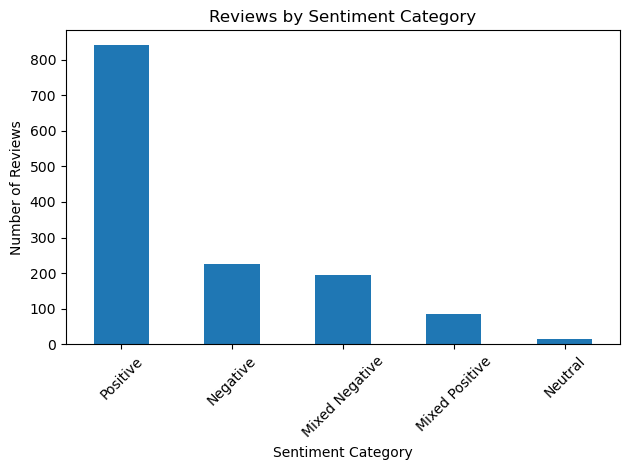

In [45]:
sentiment_counts = customer_reviews_df['SentimentCategory'].value_counts()

sentiment_counts.plot(kind='bar')

plt.title('Reviews by Sentiment Category')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()